A note about using generative AI to assist with debugging and code suggestions:

We used Gemini to identify errors in our code and used its suggestions to fix them.

In [ ]:
#upload SA and QOI files from drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import numpy as np
from re import S
import random
from scipy import stats
%matplotlib inline

length of st: 35


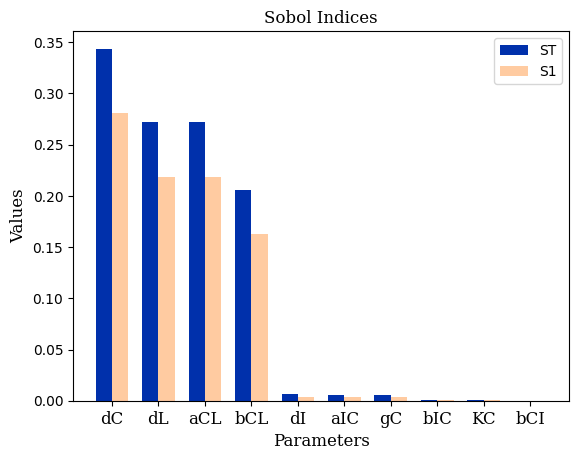

In [ ]:
#plotting Sobol Indices

#reading in data from matlab SA results
SA_values = pd.read_csv('/content/drive/MyDrive/3milSAValues.txt', sep = ',', header=None, names=['S1', 'ST'])
SA_values = SA_values.assign(param = ['params', 'lL', 'dA', 'sR', 'dR', 'aIR', 'bIR', 'aCI', 'bCI', 'aHI', 'bHI', 'lC', 'gC', 'KC',
                                      'aIC', 'bIC', 'lH', 'gH', 'KH', 'aIH', 'bIH', 'lR', 'dI', 'aHC', 'bHC', 'dC', 'aAH',
                                      'bAH', 'aRA', 'bRA', 'aIRA', 'bIRA', 'dH', 'dL', 'aCL', 'bCL'])

#deleting first entry which is column title, then sorting by ST
SA_values = SA_values.iloc[1:]
#converting the 'ST' column to numeric, handling potential errors (sorting wasn't working without this step)
SA_values['ST'] = pd.to_numeric(SA_values['ST'], errors='coerce')
print(f"length of st: {len(SA_values['ST'])}")
SA_values = SA_values.sort_values('ST', ascending=False)
SA_values = SA_values.head(10) # this line selects the top 10 influential parameters to display

#setting up to plot
categories = ['ST', 'S1']
ST = SA_values['ST']
S1 = SA_values['S1']


#convert to float to avoid potential errors (graph wasn't working without this)
ST = ST.astype(float)
S1 = S1.astype(float)


#x axis is parameter names
x = SA_values['param']
x_pos = np.arange(len(x)) #need for bar placement


#setting the width of each bar
bar_width = 0.35

#creating the figure and axes
fig, ax = plt.subplots()

#plotting the ST and S1 bars
rectsST = ax.bar(x_pos - bar_width/2, ST, bar_width, label='ST', color = '#0030ab')
rectsS1 = ax.bar(x_pos + bar_width/2, S1, bar_width, label='S1', color = '#ffcba1', alpha = 1)

#adding labels, title, and legend
#updating xticklabels to reflect the actual param names instead of just 'ST' and 'S1'
font = fm.FontProperties(family='serif', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x, fontproperties = font)
ax.set_xlabel('Parameters', fontproperties=font)
ax.set_ylabel('Values', fontproperties=font)
ax.set_title('Sobol Indices', fontproperties=font)
ax.legend(prop=font)
ax.legend()

#showing the plot
plt.show()

length of st: 35


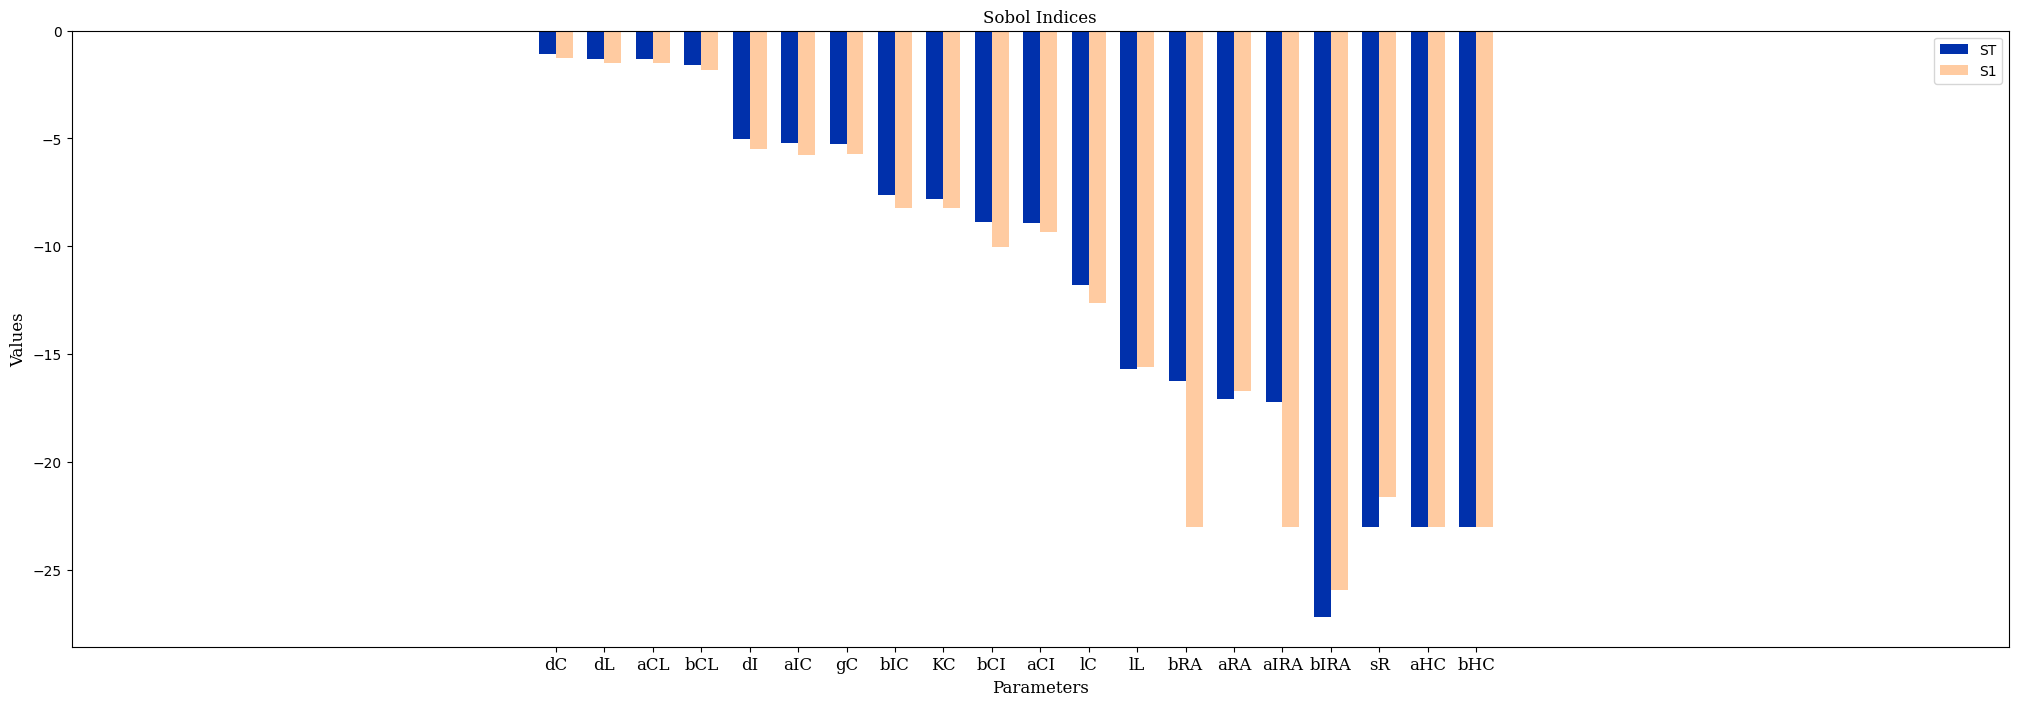

In [ ]:
#plotting Sobol Indices using log scale, not used in manuscript

#reading in data from matlab SA results
SA_values = pd.read_csv('/content/drive/MyDrive/3milSAValues.txt', sep = ',', header=None, names=['S1', 'ST'])
SA_values = SA_values.assign(param = ['params', 'lL', 'dA', 'sR', 'dR', 'aIR', 'bIR', 'aCI', 'bCI', 'aHI', 'bHI', 'lC', 'gC', 'KC',
                                      'aIC', 'bIC', 'lH', 'gH', 'KH', 'aIH', 'bIH', 'lR', 'dI', 'aHC', 'bHC', 'dC', 'aAH',
                                      'bAH', 'aRA', 'bRA', 'aIRA', 'bIRA', 'dH', 'dL', 'aCL', 'bCL'])

#deleting first entry which is column title, then sorting by ST
SA_values = SA_values.iloc[1:]
#converting the 'ST' column to numeric, handling potential errors (sorting wasn't working without this step)
SA_values['ST'] = pd.to_numeric(SA_values['ST'], errors='coerce')
print(f"length of st: {len(SA_values['ST'])}")
SA_values = SA_values.sort_values('ST', ascending=False)
SA_values = SA_values.head(20) # this line selects the top 10 influential parameters to display



#setting up to plot
categories = ['ST', 'S1']
ST = SA_values['ST']
S1 = SA_values['S1']


#convert to float to avoid potential errors (graph wasn't working without this)
ST = ST.astype(float)
S1 = S1.astype(float)
#converting to log base e
ST = np.log(ST.where(ST > 0, 1e-10)) # Replace negative values with a small positive value before taking the log
S1 = np.log(S1.where(S1 > 0, 1e-10))

#x axis is parameter names
x = SA_values['param']
x_pos = np.arange(len(x)) #need for bar placement
positions = [0]*35

for i, pos in enumerate(positions):
  pos = (i+1)*5


#setting the width of each bar
bar_width = 0.35

#creating the figure and axes
fig, ax = plt.subplots(figsize=(25, 8))

#plotting the ST and S1 bars
rectsST = ax.bar(x_pos - bar_width/2, ST, bar_width, label='ST', color = '#0030ab')
rectsS1 = ax.bar(x_pos + bar_width/2, S1, bar_width, label='S1', color = '#ffcba1', alpha = 1)


#adding labels, title, and legend
#updating xticklabels to reflect the actual param names instead of just 'ST' and 'S1'
font = fm.FontProperties(family='serif', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x, fontproperties = font)
ax.set_xlim(-10, len(x) + 10)

ax.set_xlabel('Parameters', fontproperties=font)
ax.set_ylabel('Values', fontproperties=font)
ax.set_title('Sobol Indices', fontproperties=font)
ax.legend(prop=font)
ax.legend()


#showing the plot
plt.show()

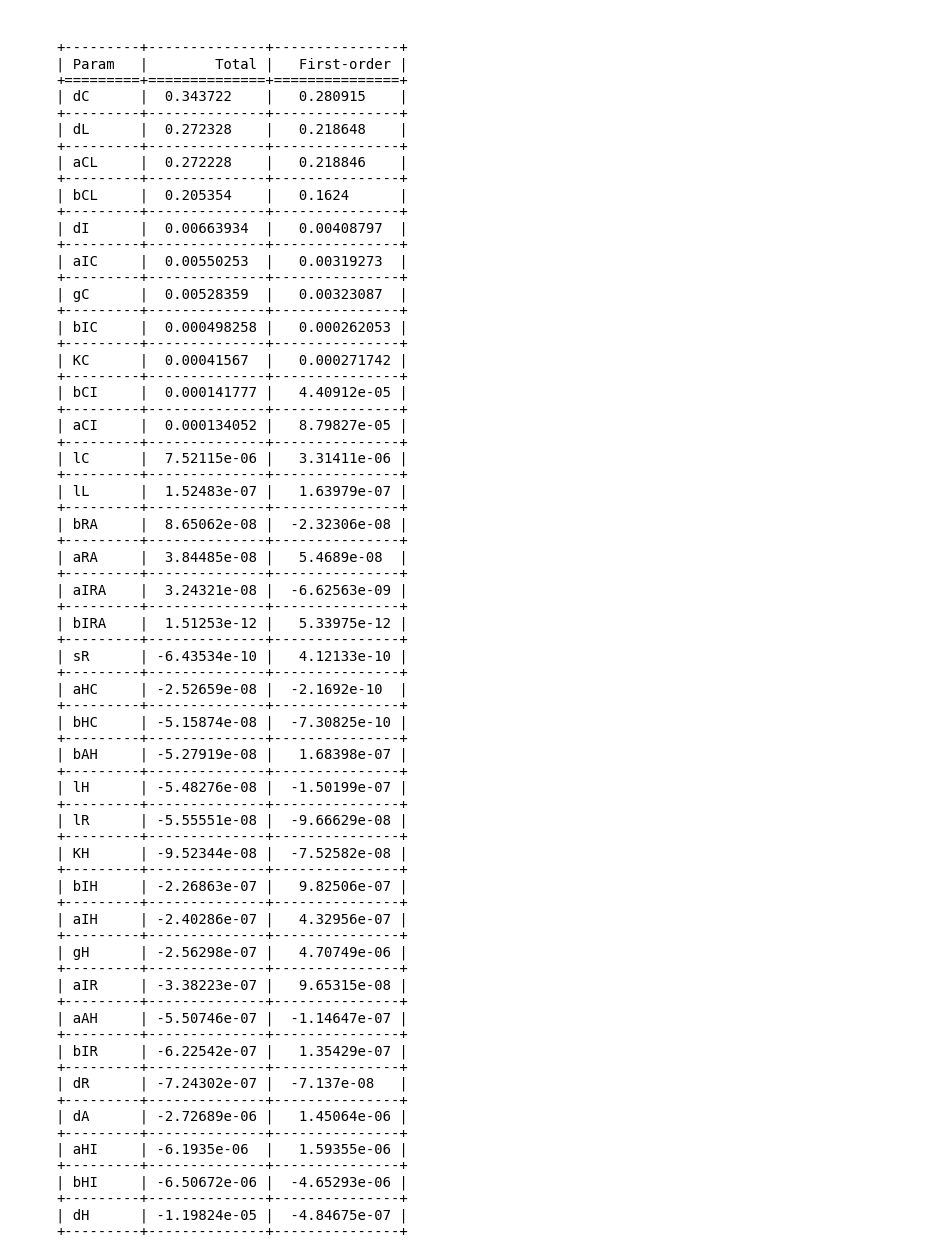

In [ ]:
#making copy and pastable table of sobol indices, NOT used in paper

!pip install tabulate

import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

#reading in data from matlab SA results
SA_values = pd.read_csv('/content/drive/MyDrive/3milSAValues.txt', sep = ',', header=None, names=['S1', 'ST'])
SA_values = SA_values.assign(param = ['params', 'lL', 'dA', 'sR', 'dR', 'aIR', 'bIR', 'aCI', 'bCI', 'aHI', 'bHI', 'lC', 'gC', 'KC',
                                      'aIC', 'bIC', 'lH', 'gH', 'KH', 'aIH', 'bIH', 'lR', 'dI', 'aHC', 'bHC', 'dC', 'aAH',
                                      'bAH', 'aRA', 'bRA', 'aIRA', 'bIRA', 'dH', 'dL', 'aCL', 'bCL'])

#deleting first entry which is column title, then sorting by ST
SA_values = SA_values.iloc[1:]
SA_values['ST'] = pd.to_numeric(SA_values['ST'], errors='coerce')
SA_values = SA_values.sort_values('ST', ascending=False)

# Creating the table data
table_data = []
for index, row in SA_values.iterrows():
    table_data.append([row['param'], row['ST'], row['S1']])

# Creating the table using tabulate
headers = ["Param", "Total", "First-order"]
table_string = tabulate(table_data, headers=headers, tablefmt="grid")

# Creating the figure and axes
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust figsize as needed

# Removing axes and spines
ax.axis('off')
for spine in ax.spines.values():
    spine.set_visible(False)

# Displaying the table as text
ax.text(0.05, 0.95, table_string, fontsize=10, family='monospace', verticalalignment='top')

# Saving the figure as an image
plt.savefig('sobol_table.png', bbox_inches='tight', dpi=300)  # Adjust dpi for quality
plt.show()

In [ ]:
#this block plots the CDFs of QOI distributions when
#sampling with all parameters varying and then the 7
#most influential parameters varying

#we ended up not showing the CDFs since the same information is shown in the PDFs, but keeping them here anyway


# loading SA files
file_path_ALL = '/content/drive/MyDrive/3milALLCELLS.txt'
file_path_SEVEN = '/content/drive/MyDrive/3milSEVENCELLS.txt'


#set a seed
np.random.seed(59)
ALLCELLS = np.random.choice(np.loadtxt(file_path_ALL, delimiter=','), 900000, replace=True) #taking subset of ALLCELLS so length matches SEVENCELLS
SEVENCELLS = np.loadtxt(file_path_SEVEN, delimiter=',')

# getting data of the histogram
countALL, bins_count = np.histogram(ALLCELLS, bins=10000)
countSEVEN, bins_count1 = np.histogram(SEVENCELLS, bins=10000)

# finding the PDF of the histogram using count values
pdfALL = countALL / sum(ALLCELLS)
pdfSEVEN = countSEVEN / sum(SEVENCELLS)

# using numpy np.cumsum to calculate the CDF
#cdfALL = np.cumsum(pdfALL) / sum(pdfALL)
#cdfSEVEN = np.cumsum(pdfSEVEN) / sum(pdfSEVEN)



# plotting CDFs
#plt.plot(bins_count1[1:], cdfSEVEN, label="CDF_SEVEN", linewidth = 4)
#plt.plot(bins_count[1:], cdfALL, color="red", label="CDF_ALL", linewidth = 2.5, linestyle='--',)
#font = fm.FontProperties(family='serif', size=12)
#plt.xlabel('QOI Value', fontproperties=font)
#plt.ylabel('Cumulative Probability', fontproperties=font)
#plt.title('CDF Comparison', fontproperties=font)
#plt.legend()



length of SEVENCELLS: 900000
length of ALLCELLS: 900000


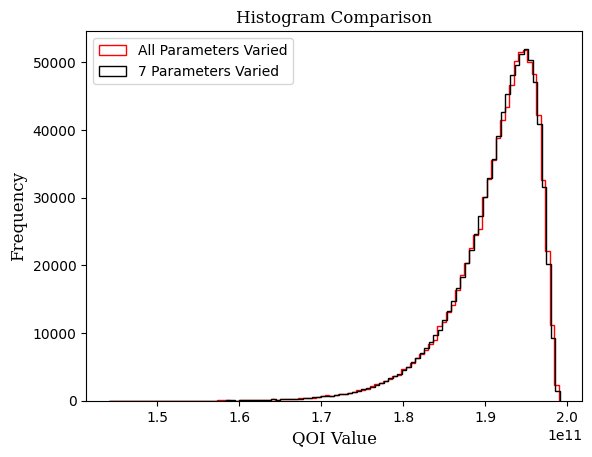

In [ ]:
#plotting PDFs of QOIs with all parameters varying vs 7 varying
np.random.seed(59)
ALLCELLS = np.random.choice(np.loadtxt(file_path_ALL, delimiter=','), 900000, replace=False) #taking subset of ALLCELLS so length matches SEVENCELLS
SEVENCELLS = np.loadtxt(file_path_SEVEN, delimiter=',')

plt.hist(ALLCELLS, bins=100, histtype = 'step', edgecolor = 'red')
plt.hist(SEVENCELLS, bins = 100, histtype = 'step', edgecolor = 'black')

#creating custom legend handles
all_cells_handle = mpatches.Patch(facecolor='white', edgecolor='red', label='All Parameters Varied', alpha=1)
seven_cells_handle = mpatches.Patch(facecolor='white', edgecolor = 'black', alpha = 1.0, label='7 Parameters Varied')


#updating legend
plt.legend(handles=[all_cells_handle, seven_cells_handle])
font = fm.FontProperties(family='serif', size=12)
plt.title("Histogram Comparison", fontproperties = font)
plt.xlabel("QOI Value", fontproperties = font)
plt.ylabel("Frequency", fontproperties = font)

print(f"length of SEVENCELLS: {len(SEVENCELLS)}") #verifying lengths of datasets are the same
print(f"length of ALLCELLS: {len(ALLCELLS)}")

In [ ]:
#this block plots the CDFs of QOI distributions
#when sampling with all parameters varying and then the
#28 least influential parameters, again we ended up not using the CDFs

#loading SA files and resampling ALLCELLS

np.random.seed(59)
ALLCELLS = np.random.choice(np.loadtxt(file_path_ALL, delimiter=','), 3000000, replace=False) #taking subset of ALLCELLS so length matches TWENTYEIGHTCELLS
file_path_TWENTYEIGHT = '/content/drive/MyDrive/3milTWENTYEIGHTCELLS.txt'
TWENTYEIGHTCELLS = np.loadtxt(file_path_TWENTYEIGHT, delimiter=',')


# getting data of the histogram
countALL, bins_count = np.histogram(ALLCELLS, bins=10000)
countTWENTYEIGHT, bins_count1 = np.histogram(TWENTYEIGHTCELLS, bins=10000)

# finding the PDF of the histogram using count values
pdfALL = countALL / sum(ALLCELLS)
pdfTWENTYEIGHT = countTWENTYEIGHT / sum(TWENTYEIGHTCELLS)

# using numpy np.cumsum to calculate the CDF
#cdfALL = np.cumsum(pdfALL) / sum(pdfALL)
#cdfTWENTYEIGHT = np.cumsum(pdfTWENTYEIGHT) / sum(pdfTWENTYEIGHT)

# plotting CDFs
#plt.plot(bins_count[1:], cdfALL, color="red", label="CDF_ALL")
#plt.plot(bins_count1[1:], cdfTWENTYEIGHT, color ='green', label="CDF_TWENTY_EIGHT")
#plt.legend()
#plt.xlabel('QOI Value', fontproperties=font)
#plt.ylabel('Cumulative Probability', fontproperties=font)
#plt.title('CDF Comparison', fontproperties=font)
#plt.legend()
#plt.show()

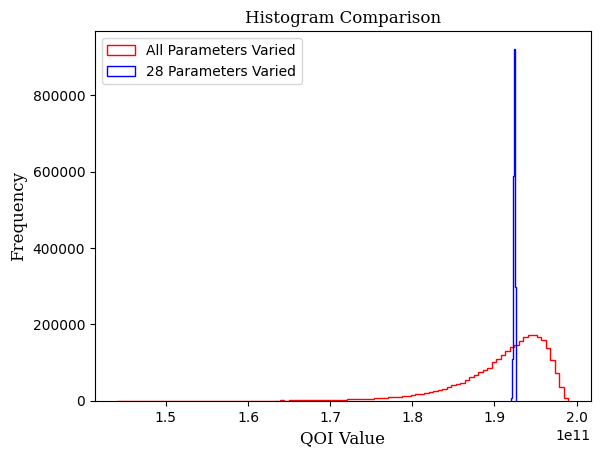

In [ ]:
#plotting PDFs of 28

plt.hist(ALLCELLS, alpha=1, bins = 100, histtype = 'step', color='red')
plt.hist(TWENTYEIGHTCELLS, bins = 10, histtype = 'step', edgecolor='blue') #had to offset bins since the spread of TWENTYEIGHTCELLS is so tiny


#creating custom legend handles
all_cells_handle = mpatches.Patch(facecolor='white', edgecolor='red', label='All Parameters Varied', alpha=1)
twentyeight_cells_handle = mpatches.Patch(facecolor='white', edgecolor = 'blue', alpha = 1.0, label='28 Parameters Varied')


#updating legend
plt.legend(handles=[all_cells_handle, twentyeight_cells_handle])
font = fm.FontProperties(family='serif', size=12)
plt.title("Histogram Comparison", fontproperties = font)
plt.xlabel("QOI Value", fontproperties = font)
plt.ylabel("Frequency", fontproperties = font)
plt.show()

In [ ]:
#run two sample ks test
ks_2sample = stats.ks_2samp(ALLCELLS, SEVENCELLS)
print(ks_2sample)

#different sample size
bigALLCELLS = file_path_ALL
ks_2sample = stats.ks_2samp(bigALLCELLS, SEVENCELLS)
print(ks_2sample)

KstestResult(statistic=0.0021960000000000313, pvalue=0.0025149152192636, statistic_location=192027985035.7, statistic_sign=1)
KstestResult(statistic=1.0, pvalue=0.0, statistic_location='/content/drive/MyDrive/3milALLCELLS.txt', statistic_sign=1)
